<a href="https://colab.research.google.com/github/BilalKhaliqWillis/BILAL-Assignment2/blob/main/Text_Classification_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Text Classification Assignment


## Step 1: Upload Dataset

In [13]:
from google.colab import files
uploaded = files.upload()

Saving trec_data.csv to trec_data (2).csv


## Step 2: Load Dataset

In [14]:
import pandas as pd

df = pd.read_csv('trec_data.csv')
df.head()

,label-coarse,text
0,0,how did serfdom develop in and then leave russ...
1,1,what films featured the character popeye doyle ?
2,0,how can i find a list of celebrities ' real na...
3,1,what fowl grabs the spotlight after the chines...
4,2,what is the full form of .com ?


## Step 3: Text Preprocessing

In [15]:
import nltk

# Download required resources
nltk.download('punkt')
nltk.download('punkt_tab')   # Fix for LookupError
nltk.download('stopwords')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess(text):
    text = str(text).lower()   # safe conversion to string
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word.isalpha()]
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [stemmer.stem(word) for word in tokens]
    return " ".join(tokens)

df['cleaned_text'] = df['text'].apply(preprocess)

df.head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,label-coarse,text,cleaned_text
0,0,how did serfdom develop in and then leave russ...,serfdom develop leav russia
1,1,what films featured the character popeye doyle ?,film featur charact popey doyl
2,0,how can i find a list of celebrities ' real na...,find list celebr real name
3,1,what fowl grabs the spotlight after the chines...,fowl grab spotlight chines year monkey
4,2,what is the full form of .com ?,full form


## Step 4: Train-Test Split

In [16]:
from sklearn.model_selection import train_test_split

X = df['cleaned_text']
y = df['label-coarse']   # ✅ correct column name

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Step 5: TF-IDF Feature Engineering

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

## Step 6: GloVe Embeddings using spaCy

In [18]:
!python -m spacy download en_core_web_md

import spacy
nlp = spacy.load('en_core_web_md')

def get_doc_vector(text):
    return nlp(text).vector

import numpy as np

X_train_glove = np.array([get_doc_vector(text) for text in X_train])
X_test_glove = np.array([get_doc_vector(text) for text in X_test])

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 41.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## Step 7: Model Training (SGDClassifier)

In [19]:
from sklearn.linear_model import SGDClassifier

model_tfidf = SGDClassifier(loss='hinge', penalty='l2', alpha=1e-3, max_iter=1000, random_state=42)
model_glove = SGDClassifier(loss='hinge', penalty='l2', alpha=1e-3, max_iter=1000, random_state=42)

model_tfidf.fit(X_train_tfidf, y_train)
model_glove.fit(X_train_glove, y_train)

SGDClassifier(alpha=0.001, random_state=42)

## Step 8: Model Evaluation

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predictions
y_pred_tfidf = model_tfidf.predict(X_test_tfidf)
y_pred_glove = model_glove.predict(X_test_glove)

# Metrics
metrics = {
    "TF-IDF": {
        "Accuracy": accuracy_score(y_test, y_pred_tfidf),
        "Precision": precision_score(y_test, y_pred_tfidf, average='weighted'),
        "Recall": recall_score(y_test, y_pred_tfidf, average='weighted'),
        "F1-Score": f1_score(y_test, y_pred_tfidf, average='weighted')
    },
    "GloVe": {
        "Accuracy": accuracy_score(y_test, y_pred_glove),
        "Precision": precision_score(y_test, y_pred_glove, average='weighted'),
        "Recall": recall_score(y_test, y_pred_glove, average='weighted'),
        "F1-Score": f1_score(y_test, y_pred_glove, average='weighted')
    }
}

metrics

{'TF-IDF': {'Accuracy': 0.7158570119156737,
  'Precision': 0.7164968873791042,
  'Recall': 0.7158570119156737,
  'F1-Score': 0.7147489941594126},
 'GloVe': {'Accuracy': 0.5307057745187901,
  'Precision': 0.5329687018333182,
  'Recall': 0.5307057745187901,
  'F1-Score': 0.5273461047296533}}

## Step 9: Results Table

In [21]:
results_df = pd.DataFrame(metrics).T
results_df

,Accuracy,Precision,Recall,F1-Score
TF-IDF,0.715857,0.716497,0.715857,0.714749
GloVe,0.530706,0.532969,0.530706,0.527346


## Step 10: Plot Comparison

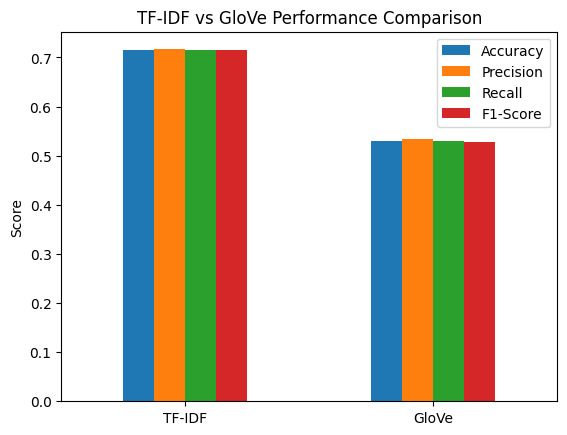

In [22]:
import matplotlib.pyplot as plt

results_df.plot(kind='bar')
plt.title("TF-IDF vs GloVe Performance Comparison")
plt.xticks(rotation=0)
plt.ylabel("Score")
plt.show()